In [1]:
from rabtracks import *
sns.set_context("paper")

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered

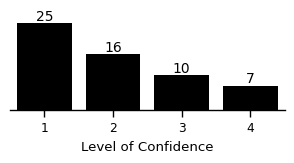

In [3]:
eib = xr.open_dataset("../RABTracks/RABTracks_NA.nc")
eib = clean(eib.sel(source = [
# 'SyCLoPS-ERA5',
# 'SyCLoPS-JRA3Q',
# 'SyCLoPS-MERRA2',
 'TRACK-ERA5',
 'TRACK-JRA3Q',
 'TRACK-MERRA2',
 'TRACK-NCEP', 
]).where(
    (eib.time.dt.year >= 1980) & (eib.time.dt.year <= 2022) &
    (eib.lon >= -15) & (eib.lon <= 20) & 
    (eib.lat >= 30) & (eib.lat <= 60)
))

CTO_FR = pd.DataFrame()
for s in [
# 'SyCLoPS-ERA5',
# 'SyCLoPS-JRA3Q',
# 'SyCLoPS-MERRA2',
 'TRACK-ERA5',
 'TRACK-JRA3Q',
 'TRACK-MERRA2',
 'TRACK-NCEP', ]:
    eib_s = eib.sel(source = s)
    eib_s = clean(eib_s.where(eib_s.track_id.notnull()))
    eib_s = eib_s.hrcn.interp_time("1h")
    eib_s = eib_s.hrcn.add_country()
    CTO_FR = pd.concat([CTO_FR, (eib_s.country == "France").groupby(eib_s.track_id).max().to_dataframe().reset_index()])
C = CTO_FR.pivot_table(index = "track_id", columns = "source", values = "country").fillna(0).sum(axis = 1)
CTO_FR.pivot_table(index = "track_id", columns = "source", values = "country").fillna(0).sum()

sns.set_context("paper")

fig = plt.figure(figsize = cm2inch([9,3]))
X = np.arange(1,5)
Y = []
for n in X:
    Y.append((C >= n).sum())
ax = sns.barplot(x=X, y=Y, estimator="sum", errorbar=None, color = "k")
ax.bar_label(ax.containers[0], fontsize=10);
sns.despine(left = True)
ax.yaxis.set_visible(False)
ax.set_xlabel("Level of Confidence")
#ax.set_title("Number of CTO reaching France\nover 1980-2022")

plt.savefig("conf_level_CTO_in_France.png", bbox_inches = "tight")
plt.savefig("conf_level_CTO_in_France.pdf", bbox_inches = "tight")

N, Y = [], []
for tid in C[C == 4].index.values:
    N.append(clean(eib.where(eib.track_id == tid)).name.max().values)
    Y.append(eib.where(eib.track_id == tid).time.dt.year.mean().values)
    print(clean(eib.where(eib.track_id == tid)).name.max().values, 
          clean(eib.where(eib.track_id == tid)).time.dt.year.mean().values)

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered

IVAN 1998.0
JEANNE 1998.0
VINCE 2005.0
GORDON 2012.0
RAFAEL 2012.0
UNNAMED 2017.0
LESLIE 2018.0
MICHAEL 2018.0
ALPHA 2020.0


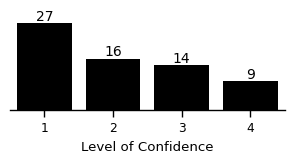

In [4]:
# Spain
CTO_FR = pd.DataFrame()
for s in [
 'TRACK-ERA5',
 'TRACK-JRA3Q',
 'TRACK-MERRA2',
 'TRACK-NCEP', ]:
    eib_s = eib.sel(source = s)
    eib_s = clean(eib_s.where(eib_s.track_id.notnull()))
    eib_s = eib_s.hrcn.interp_time("1h")
    eib_s = eib_s.hrcn.add_country()
    CTO_FR = pd.concat([CTO_FR, (eib_s.country == "Spain").groupby(eib_s.track_id).max().to_dataframe().reset_index()])
C = CTO_FR.pivot_table(index = "track_id", columns = "source", values = "country").fillna(0).sum(axis = 1)
CTO_FR.pivot_table(index = "track_id", columns = "source", values = "country").fillna(0).sum()

sns.set_context("paper")

fig = plt.figure(figsize = cm2inch([9,3]))
X = np.arange(1,5)
Y = []
for n in X:
    Y.append((C >= n).sum())
ax = sns.barplot(x=X, y=Y, estimator="sum", errorbar=None, color = "k")
ax.bar_label(ax.containers[0], fontsize=10);
sns.despine(left = True)
ax.yaxis.set_visible(False)
ax.set_xlabel("Level of Confidence")

N, Y = [], []
for tid in C[C == 4].index.values:
    N.append(clean(eib.where(eib.track_id == tid)).name.max().values)
    Y.append(eib.where(eib.track_id == tid).time.dt.year.mean().values)
    print(clean(eib.where(eib.track_id == tid)).name.max().values, 
          clean(eib.where(eib.track_id == tid)).time.dt.year.mean().values)

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/user

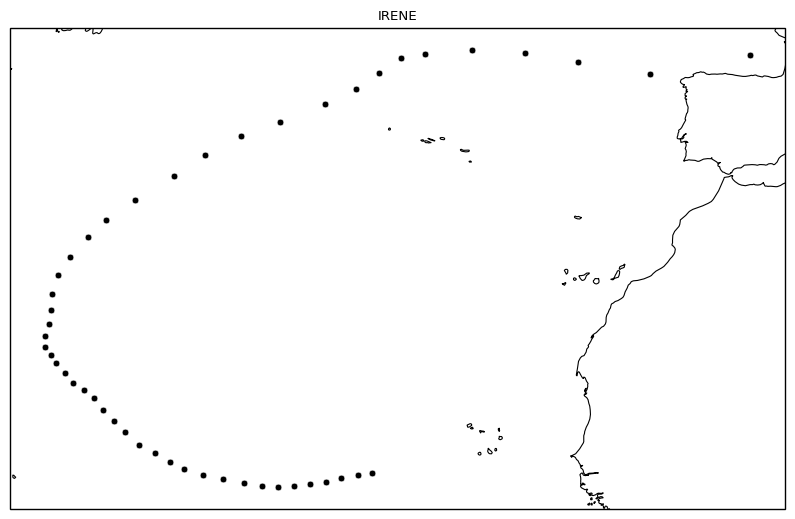

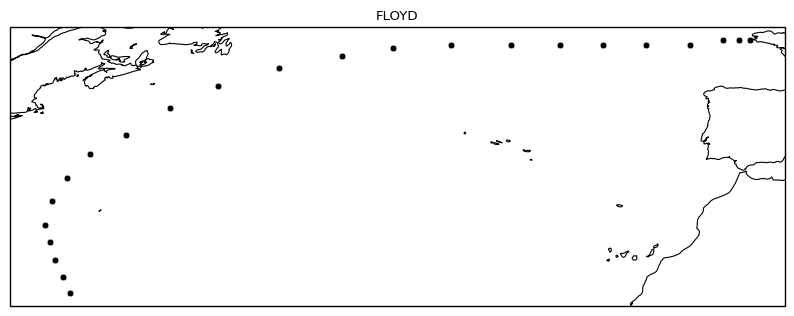

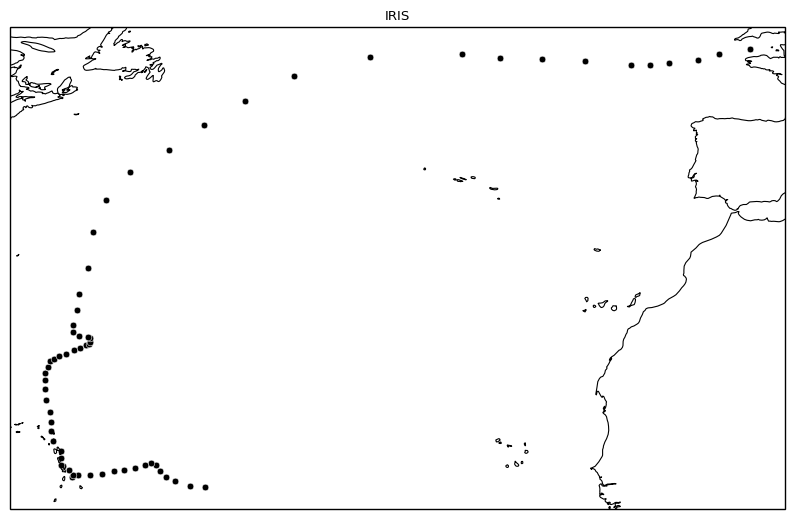

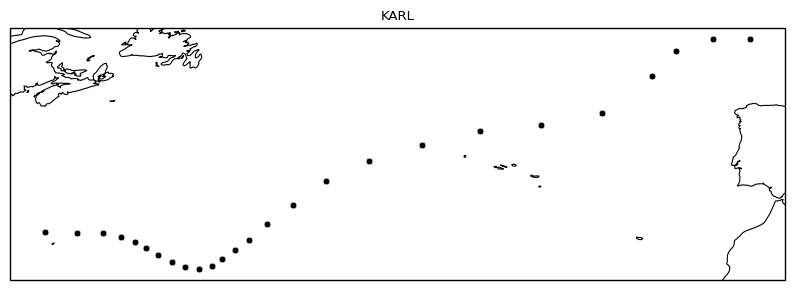

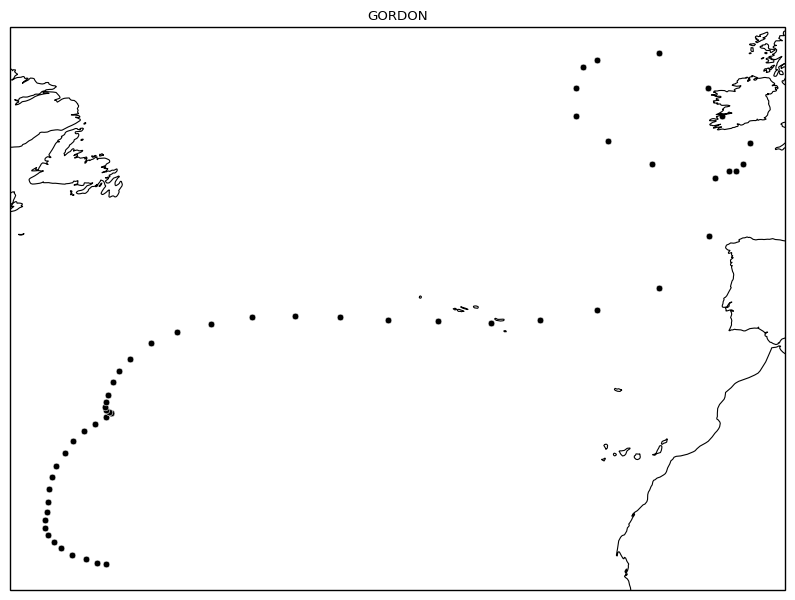

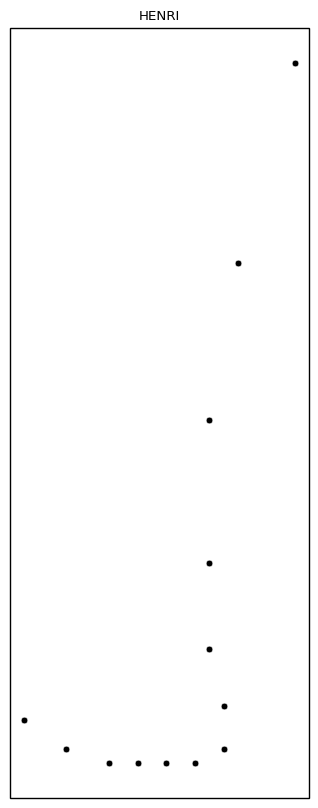

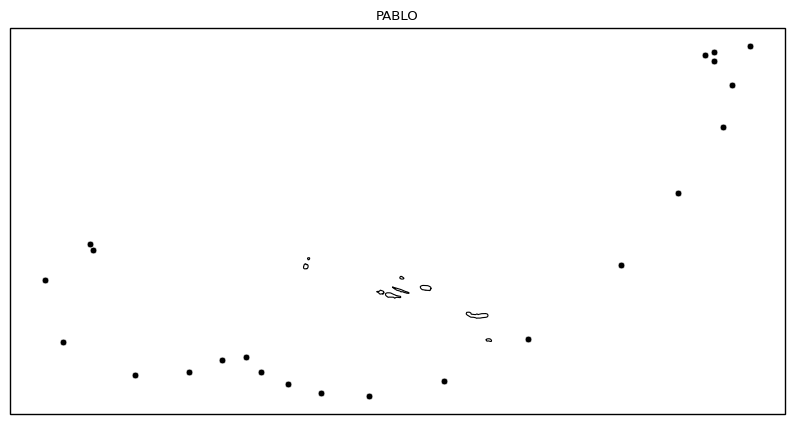

In [27]:
eib = xr.open_dataset("../RABTracks/RABTracks_NA.nc")
for n, y in zip(N, Y):
    eib.where((eib.name == n) & (eib.time.dt.year == int(y))).sel(source = "IBTrACS").hrcn.plot_tracks()
    plt.title(n)

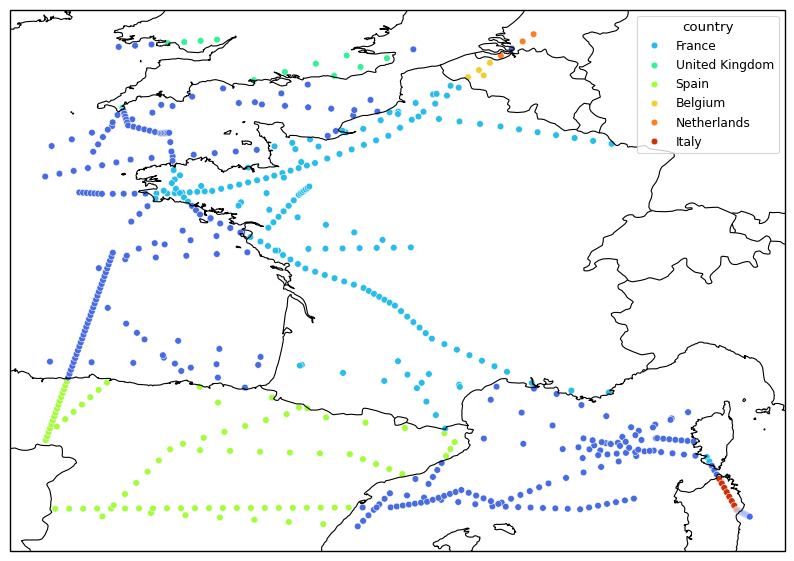

In [111]:
import cartopy.feature as cfeature
fig, ax = eib_s.hrcn.plot_tracks(subplot_kws = dict(projection = ccrs.PlateCarree()), intensity_var_name = "country")
ax.add_feature(cfeature.BORDERS.with_scale('50m'))

<Axes: xlabel='lon', ylabel='lat'>

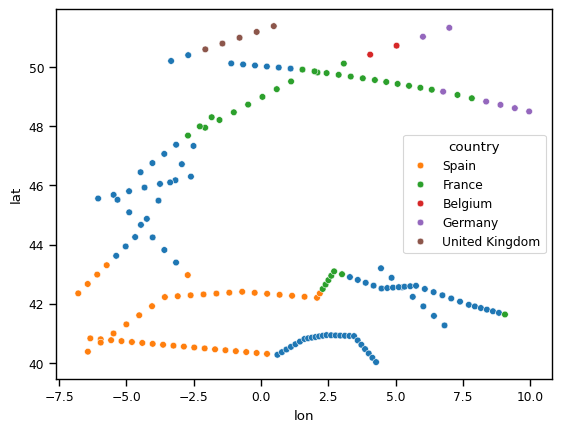

In [73]:
sns.scatterplot(data = eib_s, x = "lon", y = "lat", hue = "country")

In [53]:
eib.sel(source = "TRACK-NCEP")[["lon", "lat", "track_id"]].hrcn.interp_time("1h")

TypeError: '<' not supported between instances of 'str' and 'float'

In [22]:
from dask.diagnostics import ProgressBar

# Chunk your dataset along the looped dimension
ds_chunked = eib.chunk({"record": 10})

result = xr.apply_ufunc(
    huracanpy.info.country,
    ds_chunked["lon"],
    ds_chunked["lat"],
    input_core_dims=[["source"], ["source"]],
    output_core_dims=[["source"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[object],
)

# Compute with a progress bar
with ProgressBar():
    result = result.compute()

[########################################] | 100% Completed | 101.47 s


In [25]:
eib["country"]=  result.copy()

In [43]:
eib_df = eib.to_dataframe()

In [45]:
eib_df[eib_df.country == "France"]

lon        lat         pres     wind10  \
source         record                                                 
SyCLoPS-ERA5   117109   2.750000  49.500000  1003.713989   9.771486   
               119582   0.750000  49.750000  1014.440979   6.141222   
SyCLoPS-JRA3Q  107139 -52.875000   2.809572  1004.088989   4.376592   
               117109   1.875000  49.635761  1003.583984  14.612170   
               118323  -2.250000  47.388103  1002.510986  15.532800   
               118324  -1.125000  47.762714  1003.216003  10.545080   
               118325  -1.125000  49.261150  1003.856018  11.982090   
               119647   0.750000  43.642010  1001.924011  12.267280   
               119648  -0.750000  44.391228  1001.112976  10.232010   
               119649   3.000000  45.515057  1002.651001  13.189330   
               119650   2.250000  47.013493  1005.041992   7.703309   
               119651   3.000000  48.511932  1007.810974  13.055290   
               119652   3.000000  50.384979  1010.664978  14.707820   
               121967   1.875000  42.892792  1008.981018   9.893248   
               121968   3.000000  42.518181  1009.692993   9.594501   
               121972   6.000000  47.762714  1012.882996   5.184491   
               121976   5.625000  48.137321  1013.094971   3.772729   
               121977   6.375000  48.886539  1013.211975   3.863173   
               121978   5.625000  49.261150  1012.755981   2.895666   
               124962 -61.500000  16.295515  1005.711975  17.490879   
SyCLoPS-MERRA2 112642 -61.250000  16.000000  1010.729980   9.621924   
               113102 -61.250000  16.000000  1008.856995  15.926240   
               123156 -61.250000  16.000000  1013.765991   9.769284   
TRACK-ERA5     109919  -2.074524  47.954128  1007.554016  12.935240   
               109920   1.116813  49.519173  1006.926025   6.683336   
               113480  -1.833710  48.308826   984.876221  15.641190   
               119872   1.539700  49.919899  1023.078003  10.214100   
               119873   4.229243  49.567329  1023.263000   9.685575   
               121969   2.715379  43.095406  1011.385010   9.616611   
               121973   9.062551  41.636723  1014.463989   7.092798   
               123156 -61.671021  16.160614  1012.976013  11.715440   
TRACK-JRA3Q    112910   1.510247  49.217983  1015.479980   9.277470   
               113480  -2.510559  48.340092   984.821777  16.230009   
               119872   1.512930  49.885155  1023.161987  11.616060   
               119873   4.392480  49.648106  1023.820984  12.068790   
               121973   9.238472  41.641354  1014.903015   6.604608   
               123156 -61.635193  16.244755  1012.356018  14.703620   
TRACK-MERRA2   107684  -3.220184  48.181339  1007.622009   8.075406   
               113480  -1.651672  48.010090   985.284485  14.724930   
               114162  -0.852234  43.868374  1001.585022  11.160480   
               119873   3.968004  49.611286  1023.437988   9.606494   
               119874   6.635721  49.195522  1023.205017   9.672114   
               121970   1.505012  43.975060  1010.424011   8.119565   
               121973   8.921594  41.674477  1013.843018   7.672681   
               124962 -61.723145  16.097319  1008.883972  13.696210   
TRACK-NCEP     109920   0.802594  49.284760  1007.043030   7.473988   
               112910   1.375227  49.196270  1015.935974   9.722572   
               113480  -2.130280  48.294182   986.386597  19.140850   
               114162   1.312805  43.257782  1001.252991  17.195890   
               122635 -61.476166  16.429695  1011.817993  12.931220   
               122850  -1.368866  47.314987  1011.224976  16.866091   
               122851  -1.830872  47.363243  1012.737976  15.774740   
               122854  -1.720154  46.566219  1018.715027  11.546300   
               123156 -61.457397  16.390976  1012.783020  11.884650   
               124962 -61.387115  16.232269  1006.888

In [31]:
eib_FR = clean(eib.where(eib.country == "France"))

In [32]:
from dask.diagnostics import ProgressBar

# Chunk your dataset along the looped dimension
ds_chunked = eib_FR.chunk({"record": 10})

result = xr.apply_ufunc(
    huracanpy.info.continent,
    ds_chunked["lon"],
    ds_chunked["lat"],
    input_core_dims=[["source"], ["source"]],
    output_core_dims=[["source"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[object],
)

# Compute with a progress bar
with ProgressBar():
    result = result.compute()

[########################################] | 100% Completed | 267.53 ms


In [33]:
eib_FR["continent"] = result.copy()

In [35]:
eib_FR.where(eib_FR.continent == "Europe", drop = True)

<xarray.Dataset> Size: 171kB
Dimensions:                 (source: 7, record: 38)
Coordinates:
  * source                  (source) <U17 476B 'SyCLoPS-ERA5' ... 'TRACK-NCEP'
  * record                  (record) int64 304B 107139 107684 ... 123156 124962
Data variables: (12/87)
    lon                     (source, record) float32 1kB nan nan ... -61.39
    lat                     (source, record) float32 1kB nan nan ... 16.39 16.23
    pres                    (source, record) float32 1kB nan nan ... 1.007e+03
    wind10                  (source, record) float32 1kB nan nan ... 11.88 21.42
    vo850                   (source, record) float32 1kB nan nan ... 9.138 12.55
    label                   (source, record) object 2kB nan nan nan ... b'' b''
    ...                      ...
    WCS                     (source, record) float64 2kB nan nan nan ... 0.0 0.0
    CCA                     (source, record) float64 2kB nan nan nan ... 0.0 0.0
    is_etc                  (source, record) float64 2kB nan nan nan ... 0.0 0.0
    ET                      (source, record) float32 1kB nan nan nan ... 0.0 0.0
    country                 (record, source) object 2kB nan ... 'France'
    continent               (record, source) object 2kB nan ... 'Europe'

In [36]:
eib_FR

<xarray.Dataset> Size: 171kB
Dimensions:                 (source: 7, record: 38)
Coordinates:
  * source                  (source) <U17 476B 'SyCLoPS-ERA5' ... 'TRACK-NCEP'
  * record                  (record) int64 304B 107139 107684 ... 123156 124962
Data variables: (12/87)
    lon                     (source, record) float32 1kB nan nan ... -61.39
    lat                     (source, record) float32 1kB nan nan ... 16.39 16.23
    pres                    (source, record) float32 1kB nan nan ... 1.007e+03
    wind10                  (source, record) float32 1kB nan nan ... 11.88 21.42
    vo850                   (source, record) float32 1kB nan nan ... 9.138 12.55
    label                   (source, record) object 2kB nan nan nan ... b'' b''
    ...                      ...
    WCS                     (source, record) float64 2kB nan nan nan ... 0.0 0.0
    CCA                     (source, record) float64 2kB nan nan nan ... 0.0 0.0
    is_etc                  (source, record) float64 2kB nan nan nan ... 0.0 0.0
    ET                      (source, record) float32 1kB nan nan nan ... 0.0 0.0
    country                 (record, source) object 2kB nan ... 'France'
    continent               (record, source) object 2kB '' 'Europe' ... 'Europe'